In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Load Data**

In [2]:
df = pd.read_csv('../Data/raw/world_bank_data_2025.csv')
df.head()

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP)
0,Aruba,aw,2010,2.078141,2.453597e+09,24093.140151,NaN,11.666131,-1.223407,-2.733457,-18.752537,NaN,NaN,NaN,2.313385e+09,NaN
1,Aruba,aw,2011,4.316297,2.637859e+09,25712.384302,NaN,4.801974,4.005674,3.369237,-9.877656,NaN,NaN,NaN,2.391841e+09,NaN
2,Aruba,aw,2012,0.627472,2.615208e+09,25119.665545,NaN,8.200875,0.184033,-1.040800,3.473451,NaN,NaN,NaN,2.499118e+09,NaN
3,Aruba,aw,2013,-2.372065,2.727850e+09,25813.576727,NaN,10.709709,-1.995948,6.431483,-11.813206,NaN,NaN,NaN,2.563517e+09,NaN
4,Aruba,aw,2014,0.421441,2.790850e+09,26129.839062,NaN,3.213869,3.958897,-1.586575,-4.658577,NaN,NaN,NaN,2.688102e+09,NaN


**Understanding the data**

In [3]:
df.info()
df.describe()
df.isnull().sum()
df.isna().mean()*100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3472 entries, 0 to 3471
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country_name                     3472 non-null   object 
 1   country_id                       3472 non-null   object 
 2   year                             3472 non-null   int64  
 3   Inflation (CPI %)                2694 non-null   float64
 4   GDP (Current USD)                2933 non-null   float64
 5   GDP per Capita (Current USD)     2938 non-null   float64
 6   Unemployment Rate (%)            2795 non-null   float64
 7   Interest Rate (Real, %)          1735 non-null   float64
 8   Inflation (GDP Deflator, %)      2904 non-null   float64
 9   GDP Growth (% Annual)            2912 non-null   float64
 10  Current Account Balance (% GDP)  2563 non-null   float64
 11  Government Expense (% of GDP)    1820 non-null   float64
 12  Government Revenue (

country_name                        0.000000
country_id                          0.000000
year                                0.000000
Inflation (CPI %)                  22.407834
GDP (Current USD)                  15.524194
GDP per Capita (Current USD)       15.380184
Unemployment Rate (%)              19.498848
Interest Rate (Real, %)            50.028802
Inflation (GDP Deflator, %)        16.359447
GDP Growth (% Annual)              16.129032
Current Account Balance (% GDP)    26.180876
Government Expense (% of GDP)      47.580645
Government Revenue (% of GDP)      47.321429
Tax Revenue (% of GDP)             47.206221
Gross National Income (USD)        19.470046
Public Debt (% of GDP)             75.460829
dtype: float64

## Data Preprocessing ##

**Select Columns**

In [4]:
df = df[[
    'country_name',
    'year',
    'Inflation (CPI %)',
    'GDP Growth (% Annual)',
    'Inflation (GDP Deflator, %)',
    'GDP per Capita (Current USD)']]

In [5]:
df.columns = ['Country','Year','Inflation_CPI','GDP_Growth','Inflation_GDP_Deflator','GDP_per_Capita']
df.head()
    

,Country,Year,Inflation_CPI,GDP_Growth,Inflation_GDP_Deflator,GDP_per_Capita
0,Aruba,2010,2.078141,-2.733457,-1.223407,24093.140151
1,Aruba,2011,4.316297,3.369237,4.005674,25712.384302
2,Aruba,2012,0.627472,-1.040800,0.184033,25119.665545
3,Aruba,2013,-2.372065,6.431483,-1.995948,25813.576727
4,Aruba,2014,0.421441,-1.586575,3.958897,26129.839062


In [6]:
df[df['Year']==2025].isna().mean()*100

Country                     0.0
Year                        0.0
Inflation_CPI             100.0
GDP_Growth                100.0
Inflation_GDP_Deflator    100.0
GDP_per_Capita            100.0
dtype: float64

**Drop Missing target values**

In [7]:
df =df.dropna(subset=['Inflation_CPI'])

**Fill the misssing values using forward fill and backward fill**

In [8]:
cols =['GDP_Growth','Inflation_GDP_Deflator','GDP_per_Capita']

df[cols]= df.groupby('Country')[cols].ffill().bfill()

**Drop the missing values**

In [9]:
df=df.dropna()
df.isnull().sum()

Country                   0
Year                      0
Inflation_CPI             0
GDP_Growth                0
Inflation_GDP_Deflator    0
GDP_per_Capita            0
dtype: int64

In [10]:
df.shape

(2694, 6)

In [11]:
df.head()

,Country,Year,Inflation_CPI,GDP_Growth,Inflation_GDP_Deflator,GDP_per_Capita
0,Aruba,2010,2.078141,-2.733457,-1.223407,24093.140151
1,Aruba,2011,4.316297,3.369237,4.005674,25712.384302
2,Aruba,2012,0.627472,-1.040800,0.184033,25119.665545
3,Aruba,2013,-2.372065,6.431483,-1.995948,25813.576727
4,Aruba,2014,0.421441,-1.586575,3.958897,26129.839062


In [12]:
df.to_csv('../Data/processed/inflation_data.csv', index=False)

## Feature Engineering ##

**Creating Lag Features**

In [13]:
df['Inflation_lag1']= df.groupby('Country')['Inflation_CPI'].shift(1)
df['Inflation_lag2']= df.groupby('Country')['Inflation_CPI'].shift(2)
df['gdp_growth_lag1']= df.groupby('Country')['GDP_Growth'].shift(1)

**Drop null values from lagging**

In [14]:
df = df.dropna()

**Encode Country**

In [15]:
df=pd.get_dummies(df, columns=['Country'])


## Model Building ##

In [16]:
X =df.drop(columns=['Inflation_CPI','Year'],axis=1)
y = df['Inflation_CPI']

**Train/Test Split (TIME-AWARE)**

In [17]:
train = df[df['Year']<2021]
val =  df[df['Year']==2022]
test = df[df['Year']>=2023]

**Train, Validation, and Test Split**

A time-aware data split was used to preserve the chronological order of the observations and to avoid data leakage from future years into past years. Instead of using a random split, the dataset was divided based on year so that the model would be evaluated in a way that better reflects real-world forecasting.

The training set included all observations before `2021`, the validation set contained only data from `2022`, and the test set included data from `2023` onward. This split was chosen deliberately because the COVID-19 pandemic and its economic aftermath caused major disruptions in inflation behavior across many countries. By separating these more recent years, the model could be evaluated on its ability to generalize under unusual and volatile macroeconomic conditions.

In [18]:
X_train = train.drop(columns=['Inflation_CPI','Year'],axis=1)
y_train = train['Inflation_CPI']

X_val = val.drop(columns=['Inflation_CPI','Year'],axis=1)
y_val = val['Inflation_CPI']

X_test = test.drop(columns=['Inflation_CPI','Year'],axis=1)
y_test = test['Inflation_CPI']

**Model Pipeline**

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler    
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42,max_depth=8),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42,max_depth=3),
    'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42,max_depth=3)
}

results = []
for name,model in models.items():
    if name in ['LinearRegression','Ridge']:
        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', model)
        ])
    else:
        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', model)
        ])

    pipeline.fit(X_train,y_train)
    y_pred = pipeline.predict(X_val)

    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_val,y_pred),
        'RMSE': mean_squared_error(y_val,y_pred)**0.5,
        'R2': r2_score(y_val,y_pred)})
    
results_df = pd.DataFrame(results)
print(results_df)



               Model       MAE       RMSE        R2
0  Linear Regression  5.587175  11.023087  0.674034
1   Ridge Regression  5.561345  11.217566  0.662431
2      Random Forest  5.816150   9.569922  0.754313
3  Gradient Boosting  6.929490  15.363479  0.366795
4            XGBoost  6.883698  14.562683  0.431084


**Best Performing Model on Validation**

Based on the validation results, Random Forest is the best-performing model with the highest R² score of 0.754 and lowest RMSE of 9.57. This outperforms Ridge Regression (R²=0.662, RMSE=11.22) and other models.

**Hyperparameter Tuning**

In [20]:
from itertools import product

param_grid ={
    "n_estimators": [100, 200, 300],
    "max_depth": [5,8,12,None],
    "min_samples_split": [2,5,10],
     "min_samples_leaf": [1,2,4]
}

results = []

for n_estimators,max_depth,minsamples_split,min_samples_leaf in product(
    param_grid['n_estimators'],
    param_grid['max_depth'],
    param_grid['min_samples_split'],
    param_grid['min_samples_leaf']
):

    rf_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=minsamples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42,
            n_jobs=-1
        ))
    ])
    rf_pipeline.fit(X_train,y_train)
    y_val_pred = rf_pipeline.predict(X_val)

    results.append({
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'min_samples_split': minsamples_split,
        'min_samples_leaf': min_samples_leaf,
        'MAE': mean_absolute_error(y_val,y_val_pred),
        'RMSE': mean_squared_error(y_val,y_val_pred)**0.5,
        'R2': r2_score(y_val,y_val_pred)
    })

rf_results_df = pd.DataFrame(results).sort_values(by='MAE')
print(rf_results_df.head(10))

     n_estimators  max_depth  min_samples_split  min_samples_leaf       MAE  \
100           300        NaN                  2                 2  5.493686   
64            200        NaN                  2                 2  5.494911   
103           300        NaN                  5                 2  5.500754   
31            100        NaN                  5                 2  5.503608   
67            200        NaN                  5                 2  5.514497   
55            200       12.0                  2                 2  5.524604   
28            100        NaN                  2                 2  5.531144   
82            300        8.0                  2                 2  5.536691   
58            200       12.0                  5                 2  5.540345   
94            300       12.0                  5                 2  5.542177   

         RMSE        R2  
100  9.443540  0.760759  
64   9.518147  0.756964  
103  9.420231  0.761939  
31   9.586548  0.753459  


In [21]:
best_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])
best_rf.fit(X_train,y_train)
y_val_pred = best_rf.predict(X_val)

print(f"Best RF MAE: {mean_absolute_error(y_val,y_val_pred)}")
print(f"Best RF RMSE: {mean_squared_error(y_val,y_val_pred)**0.5}")
print(f"Best RF R2: {r2_score(y_val,y_val_pred)}")

Best RF MAE: 5.798721668322614
Best RF RMSE: 9.652950511562551
Best RF R2: 0.7500313727049241


**Random Forest Tuning Results**

Random Forest was selected for hyperparameter tuning after achieving the best baseline performance on the validation set under the revised time-based split. Several combinations of key hyperparameters were tested, including the number of trees, maximum depth, minimum samples required for splitting, and minimum samples per leaf.

The tuned Random Forest model achieved a validation MAE of `5.80`, a validation RMSE of `9.65`, and an R² score of `0.750`. These results confirm that Random Forest remained the strongest model for this dataset, providing the lowest overall prediction error and explaining a substantial proportion of the variation in inflation. Although the tuning process produced only a small change compared to the baseline Random Forest, the model continued to show the most reliable performance among all models tested.

In [22]:
y_test_pred = best_rf.predict(X_test)

print(f"Test MAE: {mean_absolute_error(y_test,y_test_pred)}")
print(f"Test RMSE: {mean_squared_error(y_test,y_test_pred)**0.5}")
print(f"Test R2: {r2_score(y_test,y_test_pred)}")

Test MAE: 3.711776198930427
Test RMSE: 8.412775002275522
Test R2: 0.6950952530730481


**Saving the Model**

In [23]:
import joblib
joblib.dump(best_rf,'../models/best_random_forest_model.pkl')

['../models/best_random_forest_model.pkl']

In [27]:
country_cols = [col for col in test.columns if col.startswith("Country_")]

pred_df = pd.DataFrame()
pred_df["Year"] = test["Year"].values
pred_df["Country"] = test[country_cols].idxmax(axis=1).str.replace("Country_", "", regex=False)
pred_df["actual_inflation"] = y_test.values
pred_df["predicted_inflation"] = y_test_pred

pred_df.to_csv("../data/predictions/test_predictions.csv", index=False)

**Prediction Preformance Graph**

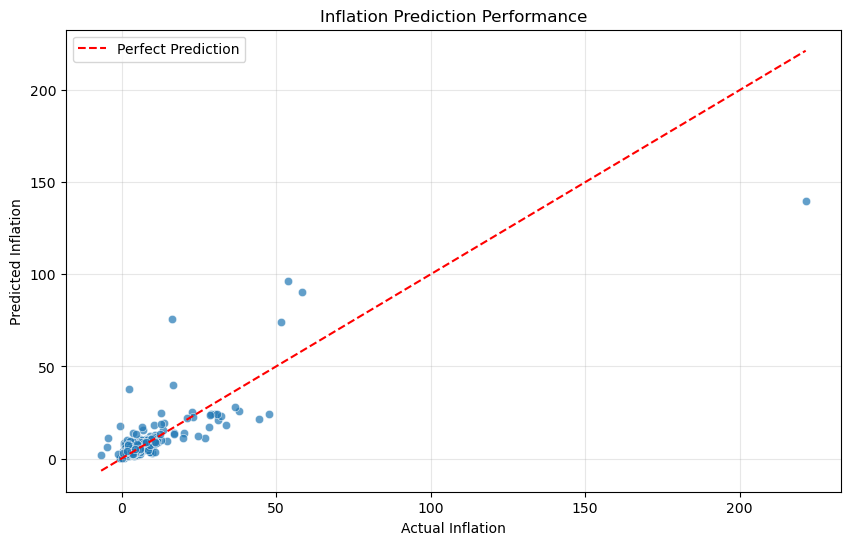

In [28]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_test_pred,alpha=0.7)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val],color='red', linestyle='--',label='Perfect Prediction')
plt.xlabel("Actual Inflation")
plt.ylabel("Predicted Inflation")
plt.title("Inflation Prediction Performance")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()